Saved.


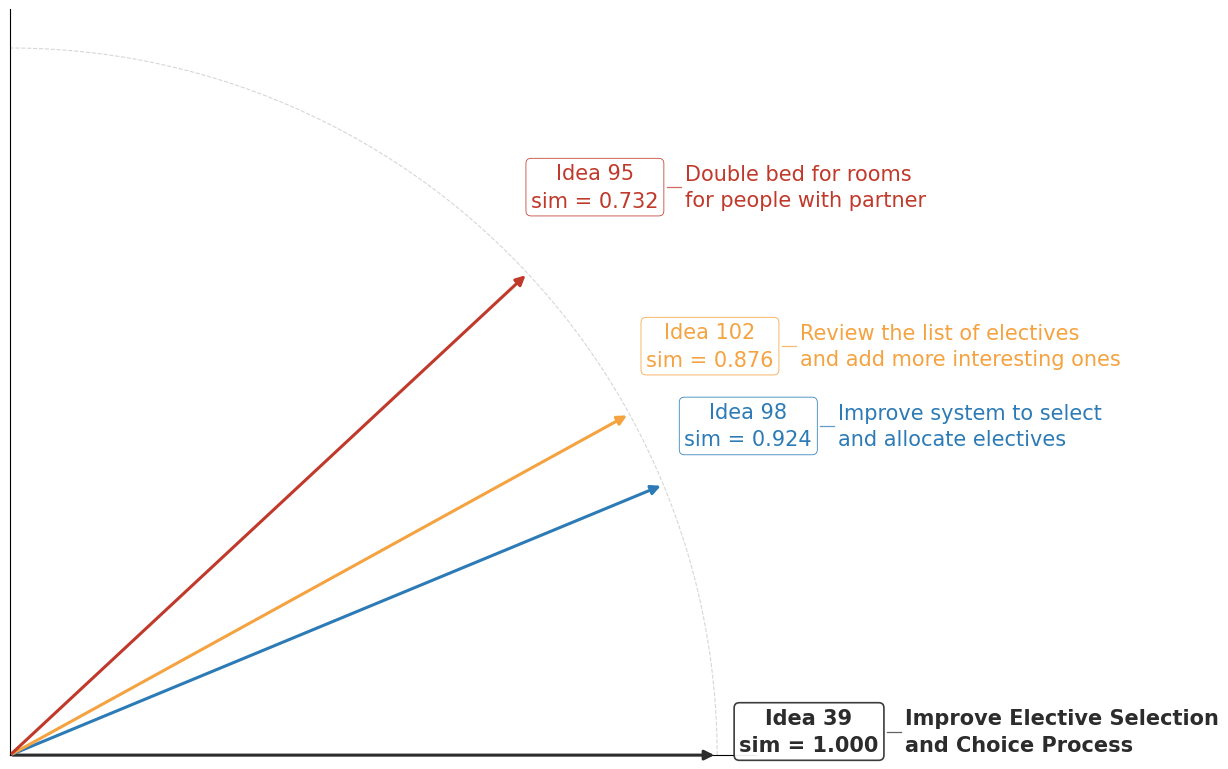

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Data: idea ID, idea title, cosine similarity
data = [
    ("Idea 39",  "Improve Elective Selection\nand Choice Process",              1.000, "#2c2c2c"),
    ("Idea 98",  "Improve system to select\nand allocate electives",            0.924, "#2c7bb6"),
    ("Idea 102", "Review the list of electives\nand add more interesting ones", 0.876, "#f4a340"),
    ("Idea 95",  "Double bed for rooms\nfor people with partner",               0.732, "#c0392b"),
]

fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": "polar"})

# Arrows
for idea_num, _, sim, color in data:
    theta = np.arccos(sim)
    ax.annotate(
        "", xy=(theta, 1), xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=2.2,
            mutation_scale=14,
        ),
    )

# Compact label boxes (Idea N + sim score)
label_texts = []
for idea_num, full_title, sim, color in data:
    theta = np.arccos(sim)
    display = f"{idea_num}\nsim = {sim:.3f}"
    fw = "bold" if sim == 1.0 else "normal"
    t = ax.text(
        theta, 1.13, display,
        ha="center", va="bottom",
        fontsize=15, fontfamily="DejaVu Sans",
        color=color, fontweight=fw, linespacing=1.45,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white", edgecolor=color,
            linewidth=1.2 if sim == 1.0 else 0.6,
            alpha=0.92,
        ),
    )
    label_texts.append((t, full_title, color, sim))

# Polar grid
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_yticklabels([])
ax.set_xticklabels([])
#ax.set_rorigin(-0.05)
ax.spines["polar"].set_visible(False)
ax.yaxis.grid(False)
ax.xaxis.grid(False)
#ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#aaaaaa", alpha=0.6)

# Faint unit-circle arc
arc_theta = np.linspace(0, np.pi / 2, 200)
ax.plot(arc_theta, np.ones_like(arc_theta),
        color="#999999", lw=0.8, ls="--", alpha=0.4, zorder=0)

# Layout
plt.tight_layout(rect=[0, 0, 0.60, 0.97])
fig.canvas.draw()

renderer = fig.canvas.get_renderer()
dpi      = fig.dpi
fig_w    = fig.get_size_inches()[0] * dpi   # figure width  in pixels
fig_h    = fig.get_size_inches()[1] * dpi   # figure height in pixels

for t, full_title, color, sim in label_texts:
    bb = t.get_window_extent(renderer=renderer)

    # Box right edge and vertical centre in figure-fraction coordinates
    right_frac = bb.x1 / fig_w
    yctr_frac  = ((bb.y0 + bb.y1) / 2) / fig_h

    # Leader line
    gap  = 8  / fig_w
    llen = 14 / fig_w
    x0   = right_frac + gap
    x1   = right_frac + gap + llen

    fig.add_artist(
        mlines.Line2D(
            [x0, x1], [yctr_frac, yctr_frac],
            transform=fig.transFigure,
            color=color, lw=0.9, alpha=0.75, clip_on=False,
        )
    )

    fig.text(
        x1 + gap * 0.5, yctr_frac, full_title,
        ha="left", va="center",
        fontsize=15, fontfamily="DejaVu Sans",
        color=color,
        fontweight="bold" if sim == 1.0 else "normal",
        linespacing=1.4,
        transform=fig.transFigure,
    )

# Save
#plt.savefig("similarity_plot.pdf", dpi=300, bbox_inches="tight")
#plt.savefig("similarity_plot.png", dpi=200, bbox_inches="tight")